# Barlow-Twins Approach Using Self-Supervised Contrastive Learning

## We use the image height crops as different views (augmentations) to train an encoder, freeze it, and then train a multiclass classifier on top of the encoder.

## **Reward Function** (Same as Hybrid Approach)
+ **Height Consistency** (Trace vs Retrace) - MAE between two values
+ **Phase Consistency** (Trace vs Retrace) - MSE between values
+ **Image Sharpness/Focus** (using gradient variance, for the CNN's image training)
+ **Signal-to-Noise Ratio of Height** (SNR, for the CNN's features training)
+ **Data Quality** (check for artifacts, clips, or excess saturation)
+ **Scan Index Penalty** (prefer earlier scans, indicating tip quality based on experiment)
+ **Scan Rate Appropriateness** (if outside of the set range of 2Hz)

```
weights = {
        'height_consistency': 0.25,
        'phase_consistency': 0.25, 
        'sharpness': 0.15,
        'snr': 0.15,
        'data_diversity': 0.1,
        'tip_freshness': 0.08,
        'scan_rate': 0.02
}

    # Weighted combination
    total_reward = sum(weights[key] * rewards[key] for key in weights.keys())
    
    return total_reward, rewards  # `rewards` is the dictionary of components
```

### Setup


In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import random

from sklearn.metrics import accuracy_score
import torch.nn.functional as F
import traceback

from utils import load_ibw

!pip install tqdm

import re
import pandas as pd
from tqdm import tqdm
import json
from datetime import datetime

!pip install seaborn

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report
import seaborn as sns

from sklearn.preprocessing import label_binarize
from itertools import cycle

^C


### Barlow Twins Encoder Training

In [ ]:
class BarlowTwinsLoss(nn.Module):
    def __init__(self, lambda_offdiag=0.0051):
        super().__init__()
        self.lambda_offdiag = lambda_offdiag

    def off_diagonal(self, x):
        n, m = x.shape
        assert n == m
        return x.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()

    def forward(self, z1, z2):
        N, D = z1.size()
        z1 = (z1 - z1.mean(0)) / z1.std(0)
        z2 = (z2 - z2.mean(0)) / z2.std(0)
        c = (z1.T @ z2) / N
        on_diag = torch.diagonal(c).add_(-1).pow_(2).sum()
        off_diag = self.off_diagonal(c).pow_(2).sum()
        return on_diag + self.lambda_offdiag * off_diag

# ----- Utility to convert AFM height array to PIL ----
def height_to_pil(height_array):
    h_min, h_max = np.min(height_array), np.max(height_array)
    norm_img = 255 * (height_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)
    pil_img = Image.fromarray(norm_img)
    return pil_img.convert("RGB")

# ----- Barlow Twins Dataset -----
class AFMBarlowDataset(Dataset):
    def __init__(self, ibw_data_list, transform=None):
        self.data = ibw_data_list  # List of numpy arrays (256x256)
        self.transform = transform

    def __len__(self):
        return len(self.data) * 9  # 9 crops per image

    def __getitem__(self, idx):
        img_idx = idx // 9
        crop_idx = idx % 9

        height_img = self.data[img_idx]
        pil_img = height_to_pil(height_img)

        crops = self._create_crops(pil_img)
        base_crop = crops[crop_idx]

        # Generate two random augmentations of the same crop
        img1 = self.transform(base_crop)
        img2 = self.transform(base_crop)
        return img1, img2

    def _create_crops(self, img, crop_size=75):
        w, h = img.size
        positions = [0, (w - crop_size) // 2, w - crop_size]
        crops = []
        for y in positions:
            for x in positions:
                crop = img.crop((x, y, x + crop_size, y + crop_size))
                crops.append(crop.resize((224, 224)))
        return crops

# ----- Main Training Loop -----
def train_barlow_twins(model, dataloader, loss_fn, optimizer, device, epochs):
    best_loss = float('inf')
    best_model_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for (x1, x2) in dataloader:
            x1, x2 = x1.to(device), x2.to(device)
            z1, z2 = model(x1), model(x2)

            loss = loss_fn(z1, z2)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x1.size(0)

        avg_loss = running_loss / len(dataloader.dataset)
        print(f"Epoch {epoch}: Barlow Twins Loss = {avg_loss:.4f}")

        # Update best model if loss improves
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_model_state = model.state_dict().copy()
            torch.save(best_model_state, "best_barlow_twins_encoder.pth")
            print(f"Saved new best model at epoch {epoch} with loss {avg_loss:.4f}")

    return best_model_state


In [ ]:
def main(NUM_EPOCHS):
    import aespm.tools as at  # Make sure this is available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    base_dir = "exp_data/June 18"
    subfolders = ["read_out", "wear_out"]
    ibw_data_list = []

    for folder in subfolders:
        folder_path = os.path.join(base_dir, folder)
        for file in sorted(os.listdir(folder_path)):
            if file.lower().endswith(".ibw"):
                ibw_path = os.path.join(folder_path, file)
                try:
                    ibw = load_ibw(ibw_path)
                    ibw_data_list.append(ibw.z)  # assumes .z is 256x256
                except Exception as e:
                    print(f"Failed to load {ibw_path}: {e}")

    print(f"Loaded {len(ibw_data_list)} IBW height images")

    # Define transforms for self-supervised learning
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    ])

    dataset = AFMBarlowDataset(ibw_data_list, transform=transform)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

    # Base encoder (ResNet18)
    encoder = models.resnet18(pretrained=False)
    encoder.fc = nn.Identity()
    model = nn.Sequential(encoder).to(device)

    # Train
    loss_fn = BarlowTwinsLoss()
    optimizer = optim.Adam(model.parameters(), lr=3e-4)
    train_barlow_twins(model, dataloader, loss_fn, optimizer, device, epochs=NUM_EPOCHS)

    # Save model
    # torch.save(model.state_dict(), "barlow_twins_encoder.pth")
    # print("Saved encoder to barlow_twins_encoder.pth")

if __name__ == "__main__":
    NUM_EPOCHS = 1000            # Define the number of epochs here
    main(NUM_EPOCHS)


Using device: cuda
Loaded 71 IBW height images


C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1: Barlow Twins Loss = 179.1499
Saved new best model at epoch 1 with loss 179.1499
Epoch 2: Barlow Twins Loss = 130.7440
Saved new best model at epoch 2 with loss 130.7440
Epoch 3: Barlow Twins Loss = 114.6221
Saved new best model at epoch 3 with loss 114.6221
Epoch 4: Barlow Twins Loss = 107.1680
Saved new best model at epoch 4 with loss 107.1680
Epoch 5: Barlow Twins Loss = 101.4436
Saved new best model at epoch 5 with loss 101.4436
Epoch 6: Barlow Twins Loss = 95.4788
Saved new best model at epoch 6 with loss 95.4788
Epoch 7: Barlow Twins Loss = 97.3811
Epoch 8: Barlow Twins Loss = 91.5443
Saved new best model at epoch 8 with loss 91.5443
Epoch 9: Barlow Twins Loss = 87.3814
Saved new best model at epoch 9 with loss 87.3814
Epoch 10: Barlow Twins Loss = 87.7152
Epoch 11: Barlow Twins Loss = 86.1959
Saved new best model at epoch 11 with loss 86.1959
Epoch 12: Barlow Twins Loss = 82.2565
Saved new best model at epoch 12 with loss 82.2565
Epoch 13: Barlow Twins Loss = 77.3436
Sav

### Training the Classifier


In [14]:
def height_to_pil(height_array):
    """Convert height numpy array to PIL Image"""
    h_min, h_max = np.min(height_array), np.max(height_array)
    norm_img = 255 * (height_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)
    pil_img = Image.fromarray(norm_img)
    return pil_img.convert("RGB")

# ----- Generate labels based on scan indices (5 classes) -----
def generate_labels_from_scan_indices(scan_indices):
    """
    Split scan indices into 5 groups as evenly as possible and assign labels 0-4.
    """
    import numpy as np
    sorted_indices = sorted(scan_indices)
    # Split into 5 nearly equal groups
    groups = np.array_split(sorted_indices, 5)
    index_to_label = {}
    for label, group in enumerate(groups):
        for idx in group:
            index_to_label[idx] = label
    # Map back to original order
    labels = [index_to_label[idx] for idx in scan_indices]
    return labels

# ----- Compute reward function (from your second script) -----
def compute_reward(ibw_data, scan_index=0):
    """
    Compute quality reward for IBW data
    """
    try:
        ch_names = ibw_data.channels
        
        # Extract data
        height_trace = ibw_data.data[ch_names.index('Height (T)')] 
        height_retrace = ibw_data.data[ch_names.index('Height (RT)')]
        phase_trace = ibw_data.data[ch_names.index('Phase (T)')] 
        phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]
        
        # Extract scan rate
        scan_rate = ibw_data.header.get('ScanRate', 1.0)
        
        rewards = {}
        
        # 1. Height Consistency (Trace vs Retrace)
        min_rows = min(height_trace.shape[0], height_retrace.shape[0])
        if min_rows > 0:
            height_diff = height_trace[:min_rows, :] - height_retrace[:min_rows, :]
            mae_height = np.mean(np.abs(height_diff))
            rewards['height_consistency'] = np.exp(-mae_height / np.std(height_trace))
        else:
            rewards['height_consistency'] = 0.0
        
        # 2. Phase Consistency 
        min_rows_phase = min(phase_trace.shape[0], phase_retrace.shape[0])
        if min_rows_phase > 0:
            phase_diff = phase_trace[:min_rows_phase, :] - phase_retrace[:min_rows_phase, :]
            phase_std = np.std(phase_diff)
            phase_range = np.ptp(phase_trace)
            if phase_range > 0:
                normalized_phase_std = phase_std / phase_range
                rewards['phase_consistency'] = np.exp(-5 * normalized_phase_std)
            else:
                rewards['phase_consistency'] = 1.0
        else:
            rewards['phase_consistency'] = 0.0
        
        # 3. Image Sharpness
        height_gradients = np.gradient(height_trace)
        gradient_variance = np.var(height_gradients)
        rewards['sharpness'] = np.tanh(gradient_variance / 1000.0)
        
        # 4. Signal-to-Noise Ratio
        height_signal = np.mean(height_trace)
        height_noise = np.std(height_trace)
        if height_noise > 0:
            snr = abs(height_signal) / height_noise
            rewards['snr'] = np.tanh(snr / 10.0)
        else:
            rewards['snr'] = 1.0
        
        # 5. Data Quality
        height_flat = height_trace.flatten()
        unique_values = len(np.unique(height_flat))
        total_pixels = len(height_flat)
        diversity_ratio = unique_values / total_pixels
        rewards['data_diversity'] = min(diversity_ratio * 10, 1.0)
        
        # 6. Scan Index Penalty (tip freshness)
        max_expected_scans = 35
        rewards['tip_freshness'] = np.exp(-scan_index / max_expected_scans)
        
        # 7. Scan Rate Appropriateness
        optimal_scan_rate = 2.0
        scan_rate_penalty = abs(scan_rate - optimal_scan_rate) / optimal_scan_rate
        rewards['scan_rate'] = np.exp(-scan_rate_penalty)
        
        # Combine rewards with weights
        weights = {
            'height_consistency': 0.15,
            'phase_consistency': 0.15, 
            'sharpness': 0.14,
            'snr': 0.14,
            'data_diversity': 0.14,
            'tip_freshness': 0.14,
            'scan_rate': 0.14
        }
        
        total_reward = sum(weights[key] * rewards[key] for key in weights.keys())
        return total_reward
        
    except Exception as e:
        print(f"Error computing reward: {e}")
        return 0.0

# ----- Enhanced Dataset with multi-class labeling and data augmentation -----
class EnhancedAFMDataset(Dataset):
    def __init__(self, ibw_data_list, scan_indices, compute_rewards=False, transform=None, 
                 use_augmentation=True, crops_per_image=9):
        """
        Enhanced dataset that uses scan indices to generate multi-class labels
        
        Args:
            ibw_data_list: list of loaded IBW data objects
            scan_indices: list of scan indices corresponding to each IBW file
            compute_rewards: whether to compute quality rewards
            transform: torchvision transforms to apply
            use_augmentation: whether to use data augmentation (crops)
            crops_per_image: number of crops per image (default 9 for 3x3 grid)
        """
        self.data = ibw_data_list
        self.scan_indices = scan_indices
        self.transform = transform
        self.use_augmentation = use_augmentation
        self.crops_per_image = crops_per_image
        
        # Generate multi-class labels from scan indices
        self.labels = generate_labels_from_scan_indices(scan_indices)
        
        print(f"Generated {len(self.labels)} labels from scan indices")
        print(f"Label distribution: {np.bincount(self.labels)}")
        
        # Compute rewards if requested
        self.rewards = None
        if compute_rewards:
            print("Computing rewards for all images...")
            self.rewards = []
            for i, data in enumerate(ibw_data_list):
                reward = compute_reward(data, scan_index=scan_indices[i])
                self.rewards.append(reward)
            
            # Normalize rewards
            self.rewards = np.array(self.rewards)
            if len(self.rewards) > 1:
                self.reward_mean = np.mean(self.rewards)
                self.reward_std = np.std(self.rewards)
                if self.reward_std > 0:
                    self.rewards = (self.rewards - self.reward_mean) / self.reward_std
                print(f"Reward normalization: mean={self.reward_mean:.4f}, std={self.reward_std:.4f}")

    def __len__(self):
        if self.use_augmentation:
            return len(self.data) * self.crops_per_image
        else:
            return len(self.data)

    def __getitem__(self, idx):
        try:
            if self.use_augmentation:
                img_idx = idx // self.crops_per_image
                crop_idx = idx % self.crops_per_image
            else:
                img_idx = idx
                crop_idx = 0
            
            # Get height data
            height_img = self.data[img_idx].z
            label = self.labels[img_idx]
            
            # Convert to PIL image
            pil_img = height_to_pil(height_img)
            
            # Create crop if using augmentation
            if self.use_augmentation:
                crop = self._create_crop(pil_img, crop_idx)
            else:
                crop = pil_img.resize((224, 224))
            
            # Apply transforms
            if self.transform:
                crop = self.transform(crop)
            
            result = [crop, label]
            
            # Add reward if computed
            if self.rewards is not None:
                result.append(self.rewards[img_idx])
            
            # Add scan index
            result.append(self.scan_indices[img_idx])
            
            return tuple(result)
            
        except Exception as e:
            print(f"Error in __getitem__ at index {idx}: {e}")
            traceback.print_exc()
            # Return fallback
            dummy_tensor = torch.zeros(3, 224, 224)
            return (dummy_tensor, 0, 0.0, 1)

    def _create_crop(self, img, idx, crop_size=75):
        """Create crop from image using 3x3 grid pattern"""
        w, h = img.size
        positions = [0, (w - crop_size) // 2, w - crop_size]
        y, x = divmod(idx, 3)
        crop = img.crop((positions[x], positions[y], 
                        positions[x] + crop_size, positions[y] + crop_size))
        return crop.resize((224, 224))

# ----- Reward-aware classifier model -----
class BarlowTwinsClassifier(nn.Module):
    def __init__(self, encoder_path, num_classes=5, include_reward_head=False, 
                 freeze_encoder=True, dropout_rate=0.3):
        """
        Classifier built on top of Barlow Twins encoder
        
        Args:
            encoder_path: path to saved Barlow Twins encoder
            num_classes: number of classification classes
            include_reward_head: whether to include reward prediction head
            freeze_encoder: whether to freeze the encoder weights
            dropout_rate: dropout rate for regularization
        """
        super(BarlowTwinsClassifier, self).__init__()
        
        # Load the Barlow Twins encoder
        self.encoder = models.resnet18(pretrained=False)
        self.encoder.fc = nn.Identity()
        
        # Wrap in Sequential to match saved state_dict format
        encoder_seq = nn.Sequential(self.encoder)
        
        # Load pretrained weights
        if os.path.exists(encoder_path):
            print(f"Loading Barlow Twins encoder from {encoder_path}")
            encoder_seq.load_state_dict(torch.load(encoder_path, map_location='cpu'))
        else:
            print(f"Warning: Encoder path {encoder_path} not found, using random initialization")
        
        self.encoder = encoder_seq[0]  # Extract the actual encoder
        
        # Freeze encoder if requested
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
            print("Encoder weights are frozen")
        
        # Get feature dimension
        feature_dim = 512  # ResNet18 feature dimension
        
        # Add dropout
        self.dropout = nn.Dropout(dropout_rate)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )
        
        # Optional reward prediction head
        self.include_reward_head = include_reward_head
        if include_reward_head:
            self.reward_predictor = nn.Sequential(
                nn.Linear(feature_dim, 128),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(128, 1)
            )
    
    def forward(self, x, return_features=False):
        # Extract features using the encoder
        features = self.encoder(x)
        features = torch.flatten(features, 1)
        features = self.dropout(features)
        
        # Classification output
        class_output = self.classifier(features)
        
        # Reward prediction if included
        reward_output = None
        if self.include_reward_head:
            reward_output = self.reward_predictor(features)
        
        if return_features:
            return class_output, reward_output, features
        else:
            if self.include_reward_head:
                return class_output, reward_output
            else:
                return class_output

# ----- Training function -----
def train_classifier(model, train_loader, val_loader, optimizer, device, 
                    num_epochs=50, use_reward_loss=False, reward_weight=0.1):
    """
    Enhanced training function with optional reward prediction
    """
    classification_criterion = nn.CrossEntropyLoss()
    reward_criterion = nn.MSELoss() if use_reward_loss else None
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                    factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        running_class_loss = 0.0
        running_reward_loss = 0.0
        correct = 0
        total = 0
        
        for i, batch_data in enumerate(train_loader):
            # Handle variable batch contents
            if len(batch_data) == 4:  # inputs, labels, rewards, scan_indices
                inputs, labels, rewards, scan_indices = batch_data
                has_rewards = True
            elif len(batch_data) == 3:  # inputs, labels, scan_indices
                inputs, labels, scan_indices = batch_data
                has_rewards = False
            else:
                continue
            
            inputs = inputs.to(device)
            labels = labels.to(device)
            if has_rewards:
                rewards = rewards.to(device)

            if rewards.dtype != torch.float32:
                rewards = rewards.float()

            optimizer.zero_grad()
            
            # Forward pass
            if model.include_reward_head:
                class_outputs, reward_outputs = model(inputs)
            else:
                class_outputs = model(inputs)
                reward_outputs = None
            
            # Compute losses
            class_loss = classification_criterion(class_outputs, labels)
            total_loss = class_loss
            
            if use_reward_loss and reward_outputs is not None and has_rewards:
                reward_loss = reward_criterion(reward_outputs.squeeze(), rewards)
                total_loss += reward_weight * reward_loss
                running_reward_loss += reward_loss.item()
            
            # Backward pass
            total_loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            # Statistics
            running_loss += total_loss.item()
            running_class_loss += class_loss.item()
            
            _, predicted = torch.max(class_outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Print progress
            if (i + 1) % 50 == 0:
                print(f"  Batch {i+1}/{len(train_loader)}, Loss: {total_loss.item():.4f}")
        
        # Validation phase
        val_loss, val_accuracy = evaluate_classifier(model, val_loader, device, 
                                                   use_reward_loss, reward_weight)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Statistics
        train_accuracy = 100 * correct / total
        avg_train_loss = running_loss / len(train_loader)
        avg_class_loss = running_class_loss / len(train_loader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"  Train Acc: {train_accuracy:.2f}% | Val Acc: {val_accuracy:.2f}%")
        print(f"  Class Loss: {avg_class_loss:.4f}")
        
        if use_reward_loss and running_reward_loss > 0:
            avg_reward_loss = running_reward_loss / len(train_loader)
            print(f"  Reward Loss: {avg_reward_loss:.4f}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_accuracy': val_accuracy,
            }, 'best_barlow_classifier.pth')
            print(f"  Saved best model (Val Loss: {val_loss:.4f})")
        
        print("-" * 60)
    
    return train_losses, val_losses

# ----- Evaluation function -----
def evaluate_classifier(model, dataloader, device, use_reward_loss=False, reward_weight=0.1):
    """Evaluate the classifier and return loss and accuracy"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    classification_criterion = nn.CrossEntropyLoss()
    reward_criterion = nn.MSELoss() if use_reward_loss else None
    
    with torch.no_grad():
        for batch_data in dataloader:
            # Handle variable batch contents
            if len(batch_data) == 4:
                inputs, labels, rewards, scan_indices = batch_data
                has_rewards = True
            elif len(batch_data) == 3:
                inputs, labels, scan_indices = batch_data
                has_rewards = False
            else:
                continue
            
            inputs = inputs.to(device)
            labels = labels.to(device)
            if has_rewards:
                rewards = rewards.to(device)
            
            # Forward pass
            if model.include_reward_head:
                class_outputs, reward_outputs = model(inputs)
            else:
                class_outputs = model(inputs)
                reward_outputs = None
            
            # Compute losses
            class_loss = classification_criterion(class_outputs, labels)
            loss = class_loss
            
            if use_reward_loss and reward_outputs is not None and has_rewards:
                reward_loss = reward_criterion(reward_outputs.squeeze(), rewards)
                loss += reward_weight * reward_loss
            
            total_loss += loss.item()
            
            # Accuracy calculation
            _, predicted = torch.max(class_outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Store for detailed metrics
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100 * correct / total
    avg_loss = total_loss / len(dataloader)
    
    return avg_loss, accuracy


In [ ]:
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Data loading parameters
    base_dir = "exp_data/June 18"
    subfolders = ["read_out", "wear_out"]
    
    # Load IBW data
    ibw_data_list = []
    scan_indices = []
    
    print("Loading IBW files...")
    for folder in subfolders:
        folder_path = os.path.join(base_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} does not exist, skipping...")
            continue
            
        files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(".ibw")])
        print(f"Found {len(files)} IBW files in {folder}")
        
        for i, file in enumerate(files):
            path = os.path.join(folder_path, file)
            try:
                ibw = load_ibw(path)
                ibw_data_list.append(ibw)
                # Extract scan index from filename or use sequential numbering
                scan_idx = i + 1  # You might want to parse this from filename
                scan_indices.append(scan_idx)
            except Exception as e:
                print(f"Error loading {path}: {e}")
    
    print(f"Successfully loaded {len(ibw_data_list)} IBW files")
    
    # Data transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Create dataset with multi-class labeling
    dataset = EnhancedAFMDataset(
        ibw_data_list, 
        scan_indices, 
        compute_rewards=True,  # Compute rewards for potential use
        transform=transform,
        use_augmentation=True,
        crops_per_image=9
    )
    
    print(f"Dataset size: {len(dataset)} samples")
    print(f"Augmentation factor: {len(dataset) / len(ibw_data_list):.1f}x")
    
    # Split dataset
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    
    # Create model
    model = BarlowTwinsClassifier(
        encoder_path="best_barlow_twins_encoder.pth",
        num_classes=5,  # Multi-class instead of binary
        include_reward_head=True,  # Include reward prediction
        freeze_encoder=True,  # Freeze encoder initially
        dropout_rate=0.3
    )
    model = model.to(device)
    
    # Print model info
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Optimizer - only optimize trainable parameters
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=1e-3, 
        weight_decay=1e-4
    )
    
    # Train the classifier
    print("\nStarting training...")
    train_losses, val_losses = train_classifier(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=400,
        use_reward_loss=True,
        reward_weight=0.1
    )
    
    # Final evaluation
    print("\nFinal evaluation on validation set:")
    val_loss, val_accuracy = evaluate_classifier(model, val_loader, device, 
                                                use_reward_loss=True, reward_weight=0.1)
    print(f"Final Validation Loss: {val_loss:.4f}")
    print(f"Final Validation Accuracy: {val_accuracy:.2f}%")
    
    # Detailed classification report
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch_data in val_loader:
            if len(batch_data) >= 2:
                inputs, labels = batch_data[0], batch_data[1]
                inputs = inputs.to(device)
                
                if model.include_reward_head:
                    class_outputs, _ = model(inputs)
                else:
                    class_outputs = model(inputs)
                
                _, predicted = torch.max(class_outputs.data, 1)
                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())
    
    print("\nDetailed Classification Report:")
    print(classification_report(all_labels, all_predictions, 
                              target_names=[f'Class {i}' for i in range(5)]))
    
    # Save final model
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'final_accuracy': val_accuracy,
    }, 'barlow_twins_multiclass_classifier.pth')
    
    print("Training completed! Model saved as 'barlow_twins_multiclass_classifier.pth'")

if __name__ == "__main__":
    main()

Using device: cuda
Loading IBW files...
Found 36 IBW files in read_out
Found 35 IBW files in wear_out
Successfully loaded 71 IBW files
Generated 71 labels from scan indices
Label distribution: [14 14 14 14 15]
Computing rewards for all images...
Reward normalization: mean=0.5976, std=0.0276
Dataset size: 639 samples
Augmentation factor: 9.0x
Training samples: 511
Validation samples: 128
Loading Barlow Twins encoder from best_barlow_twins_encoder.pth
Encoder weights are frozen
Total parameters: 11,408,198
Trainable parameters: 231,686

Starting training...
Epoch 1/400
  Train Loss: 1.7597 | Val Loss: 1.5926
  Train Acc: 21.53% | Val Acc: 32.81%
  Class Loss: 1.7597
  Reward Loss: 1.0070
  Saved best model (Val Loss: 1.5926)
------------------------------------------------------------
Epoch 2/400
  Train Loss: 1.6243 | Val Loss: 1.6236
  Train Acc: 31.70% | Val Acc: 39.06%
  Class Loss: 1.6243
  Reward Loss: 0.8824
------------------------------------------------------------
Epoch 3/400


## Validation/Analysis

In [15]:
def height_to_pil(height_array):
    """Convert AFM height array to PIL RGB image"""
    h_min, h_max = np.min(height_array), np.max(height_array)
    norm_img = 255 * (height_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)
    pil_img = Image.fromarray(norm_img)
    return pil_img.convert("RGB")

def extract_scan_index_from_filename(file_path):
    """Extract scan index from filename"""
    filename = os.path.basename(file_path)
    match = re.search(r'_(\d{4})', filename)
    if match:
        return int(match.group(1))
    match = re.search(r'(\d+)', filename)
    if match:
        return int(match.group(1))
    return 0

def create_3x3_crops(pil_img, crop_size=75):
    """Create 3x3 crops from PIL image"""
    w, h = pil_img.size
    x_positions = [0, (w - crop_size) // 2, w - crop_size]
    y_positions = [0, (h - crop_size) // 2, h - crop_size]
    crops = []
    for y in y_positions:
        for x in x_positions:
            crop = pil_img.crop((x, y, x + crop_size, y + crop_size)).resize((224, 224))
            crops.append(crop)
    return crops

def predict_single_file(model, transform, ibw_file_path, device='cpu'):
    """Predict on a single IBW file"""
    try:
        # Load IBW file - replace with your actual loading function
        ibw_data = load_ibw(ibw_file_path)
        height_img = ibw_data.z
        
        # For now, you'll need to implement your IBW loading here
        # This is a placeholder - replace with your actual loading code
        # import aespm.tools as at
        # ibw_data = at.load_ibw(ibw_file_path)  # Adjust based on your actual function
        # height_img = ibw_data.z
        
        scan_index = extract_scan_index_from_filename(ibw_file_path)
        
        # Convert to PIL and create crops
        pil_img = height_to_pil(height_img)
        crops = create_3x3_crops(pil_img)
        crop_tensors = torch.stack([transform(c) for c in crops], dim=0).to(device)

        # Make predictions
        with torch.no_grad():
            outputs = model(crop_tensors)
            probs = torch.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0)  # Average across all crops
            predicted_class = torch.argmax(avg_probs).item()
            confidence = avg_probs[predicted_class].item()
            
            # Calculate prediction consistency (how much crops agree)
            crop_predictions = torch.argmax(probs, dim=1)
            consistency = (crop_predictions == predicted_class).float().mean().item()

        return {
            "file": ibw_file_path,
            "filename": os.path.basename(ibw_file_path),
            "predicted_class": predicted_class,
            "confidence": confidence,
            "consistency": consistency,  # How many crops agreed with final prediction
            "probabilities": avg_probs.cpu().numpy().tolist(),
            "scan_index": scan_index,
            "status": "success"
        }
        
    except Exception as e:
        return {
            "file": ibw_file_path,
            "filename": os.path.basename(ibw_file_path),
            "predicted_class": None,
            "confidence": None,
            "consistency": None,
            "probabilities": None,
            "scan_index": extract_scan_index_from_filename(ibw_file_path),
            "status": "error",
            "error": str(e)
        }

def load_barlow_classifier(model_path, device='cpu'):
    """Load the trained Barlow Twins classifier with encoder and classifier submodules"""
    class BarlowClassifier(nn.Module):
        def __init__(self, num_classes=2):
            super().__init__()
            self.encoder = models.resnet18(pretrained=False)
            self.encoder.fc = nn.Identity()
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(512, num_classes)
            )
        def forward(self, x):
            x = self.encoder(x)
            x = self.classifier(x)
            return x

    # You may need to adjust num_classes if your model is multiclass
    checkpoint = torch.load(model_path, map_location=device)
    # Try to infer num_classes from checkpoint if possible
    num_classes = 2
    for k in checkpoint.keys():
        if k.startswith("classifier.2.weight"):
            num_classes = checkpoint[k].shape[0]
            break
        if k.startswith("classifier.1.weight"):
            num_classes = checkpoint[k].shape[0]
            break
        if k.startswith("classifier.4.weight"):
            num_classes = checkpoint[k].shape[0]
            break
    model = BarlowClassifier(num_classes=num_classes)
    # If checkpoint is wrapped in dict
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    # Remove any 'module.' prefix if present (from DataParallel)
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("module."):
            k = k[len("module.") :]
        new_state_dict[k] = v

    model.load_state_dict(new_state_dict, strict=False)
    model.to(device)
    model.eval()
    return model

def batch_predict_folder(model_path, data_folder, output_dir="predictions", device='cpu'):
    """
    Run predictions on all IBW files in a folder structure
    
    Args:
        model_path: Path to the trained model
        data_folder: Root folder containing IBW files (can have subfolders)
        output_dir: Directory to save results
        device: Device to run on ('cpu' or 'cuda')
    """
    
    print(f"Starting batch prediction on folder: {data_folder}")
    print(f"Using device: {device}")
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Load model
    print("Loading model...")
    model = load_barlow_classifier(model_path, device)
    
    # Setup transform
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])
    
    # Find all IBW files
    ibw_files = []
    for root, dirs, files in os.walk(data_folder):
        for file in files:
            if file.lower().endswith('.ibw'):
                ibw_files.append(os.path.join(root, file))
    
    print(f"Found {len(ibw_files)} IBW files")
    
    if len(ibw_files) == 0:
        print("No IBW files found!")
        return
    
    # Process files
    results = []
    label_map = {0: "Read Out (Tip Good)", 1: "Wear Out (Tip Worn)"}
    
    print("Processing files...")
    for ibw_file in tqdm(ibw_files, desc="Predicting"):
        result = predict_single_file(model, transform, ibw_file, device)
        
        # Add human-readable label
        if result["predicted_class"] is not None:
            result["label"] = label_map[result["predicted_class"]]
        else:
            result["label"] = "Error"
            
        # Add relative path for easier reading
        result["relative_path"] = os.path.relpath(ibw_file, data_folder)
        
        results.append(result)
    
    # Save results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Save as CSV
    df = pd.DataFrame(results)
    csv_path = os.path.join(output_dir, f"predictions_{timestamp}.csv")
    df.to_csv(csv_path, index=False)
    print(f"Results saved to: {csv_path}")
    
    # Save as JSON (more detailed)
    json_path = os.path.join(output_dir, f"predictions_detailed_{timestamp}.json")
    with open(json_path, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"Detailed results saved to: {json_path}")
    
    # Print summary statistics
    successful_predictions = [r for r in results if r["status"] == "success"]
    failed_predictions = [r for r in results if r["status"] == "error"]
    
    print(f"\n=== PREDICTION SUMMARY ===")
    print(f"Total files processed: {len(results)}")
    print(f"Successful predictions: {len(successful_predictions)}")
    print(f"Failed predictions: {len(failed_predictions)}")
    
    if successful_predictions:
        # Class distribution
        class_counts = {}
        confidence_scores = []
        consistency_scores = []
        
        for result in successful_predictions:
            label = result["label"]
            class_counts[label] = class_counts.get(label, 0) + 1
            confidence_scores.append(result["confidence"])
            consistency_scores.append(result["consistency"])
        
        print(f"\nClass Distribution:")
        for label, count in class_counts.items():
            percentage = (count / len(successful_predictions)) * 100
            print(f"  {label}: {count} files ({percentage:.1f}%)")
        
        print(f"\nAverage Confidence: {np.mean(confidence_scores):.3f} ± {np.std(confidence_scores):.3f}")
        print(f"Average Consistency: {np.mean(consistency_scores):.3f} ± {np.std(consistency_scores):.3f}")
    
    if failed_predictions:
        print(f"\nFailed files:")
        for result in failed_predictions:
            print(f"  {result['filename']}: {result['error']}")
    
    return results, csv_path, json_path

def predict_specific_subfolders(model_path, base_folder, subfolders=None, output_dir="predictions", device='cpu'):
    """
    Run predictions on specific subfolders (like your read_out and wear_out folders)
    
    Args:
        model_path: Path to trained model
        base_folder: Base directory (e.g., "exp_data/June 18")
        subfolders: List of subfolder names (e.g., ["read_out", "wear_out"])
        output_dir: Output directory
        device: Device to use
    """
    
    if subfolders is None:
        subfolders = ["read_out", "wear_out"]
    
    all_results = []
    
    for subfolder in subfolders:
        folder_path = os.path.join(base_folder, subfolder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} does not exist, skipping...")
            continue
            
        print(f"\n=== Processing {subfolder} folder ===")
        
        # Get IBW files in this subfolder
        ibw_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.ibw')]
        
        if not ibw_files:
            print(f"No IBW files found in {folder_path}")
            continue
        
        # Run predictions on this subfolder
        results, _, _ = batch_predict_folder(
            model_path, 
            folder_path, 
            output_dir=os.path.join(output_dir, subfolder),
            device=device
        )
        
        # Add ground truth labels for evaluation
        ground_truth_label = 0 if subfolder == "read_out" else 1
        for result in results:
            result["ground_truth_class"] = ground_truth_label
            result["ground_truth_label"] = "Read Out (Tip Good)" if ground_truth_label == 0 else "Wear Out (Tip Worn)"
            result["correct_prediction"] = result["predicted_class"] == ground_truth_label if result["predicted_class"] is not None else None
        
        all_results.extend(results)
    
    # Calculate overall accuracy
    successful_results = [r for r in all_results if r["status"] == "success"]
    if successful_results:
        correct_predictions = sum(1 for r in successful_results if r["correct_prediction"])
        accuracy = correct_predictions / len(successful_results)
        print(f"\n=== OVERALL ACCURACY ===")
        print(f"Accuracy: {accuracy:.3f} ({correct_predictions}/{len(successful_results)})")
        
        # Confusion matrix
        true_positives = sum(1 for r in successful_results 
                           if r["ground_truth_class"] == 1 and r["predicted_class"] == 1)
        false_positives = sum(1 for r in successful_results 
                            if r["ground_truth_class"] == 0 and r["predicted_class"] == 1)
        true_negatives = sum(1 for r in successful_results 
                           if r["ground_truth_class"] == 0 and r["predicted_class"] == 0)
        false_negatives = sum(1 for r in successful_results 
                            if r["ground_truth_class"] == 1 and r["predicted_class"] == 0)
        
        print(f"\nConfusion Matrix:")
        print(f"True Positives (Wear Out correctly identified): {true_positives}")
        print(f"False Positives (Read Out misclassified as Wear Out): {false_positives}")
        print(f"True Negatives (Read Out correctly identified): {true_negatives}")
        print(f"False Negatives (Wear Out misclassified as Read Out): {false_negatives}")
        
        if true_positives + false_negatives > 0:
            sensitivity = true_positives / (true_positives + false_negatives)
            print(f"Sensitivity (Recall for Wear Out): {sensitivity:.3f}")
        
        if true_negatives + false_positives > 0:
            specificity = true_negatives / (true_negatives + false_positives)
            print(f"Specificity (Recall for Read Out): {specificity:.3f}")
    
    return all_results

In [16]:
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Option 1: Process entire folder recursively
    # results, csv_path, json_path = batch_predict_folder(
    #     model_path="barlow_twins_classifier.pth",
    #     data_folder="exp_data/June 18",
    #     output_dir="prediction_results",
    #     device=device
    # )
    
    # Option 2: Process specific subfolders with ground truth evaluation
    results = predict_specific_subfolders(
        model_path="barlow_twins_classifier.pth",
        base_folder="exp_data/June 18",
        subfolders=["read_out", "wear_out"],
        output_dir="prediction_results",
        device=device
    )
    
    print("\nBatch prediction completed!")


=== Processing read_out folder ===
Starting batch prediction on folder: exp_data/June 18\read_out
Using device: cuda
Loading model...


C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Found 36 IBW files
Processing files...


Predicting: 100%|██████████| 36/36 [00:03<00:00, 11.18it/s]


Results saved to: prediction_results\read_out\predictions_20250625_092229.csv
Detailed results saved to: prediction_results\read_out\predictions_detailed_20250625_092229.json

=== PREDICTION SUMMARY ===
Total files processed: 36
Successful predictions: 36
Failed predictions: 0

Class Distribution:
  Read Out (Tip Good): 36 files (100.0%)

Average Confidence: 0.623 ± 0.008
Average Consistency: 1.000 ± 0.000

=== Processing wear_out folder ===
Starting batch prediction on folder: exp_data/June 18\wear_out
Using device: cuda
Loading model...
Found 35 IBW files
Processing files...


Predicting: 100%|██████████| 35/35 [00:03<00:00, 11.10it/s]

Results saved to: prediction_results\wear_out\predictions_20250625_092232.csv
Detailed results saved to: prediction_results\wear_out\predictions_detailed_20250625_092232.json

=== PREDICTION SUMMARY ===
Total files processed: 35
Successful predictions: 35
Failed predictions: 0

Class Distribution:
  Read Out (Tip Good): 35 files (100.0%)

Average Confidence: 0.552 ± 0.001
Average Consistency: 1.000 ± 0.000

=== OVERALL ACCURACY ===
Accuracy: 0.507 (36/71)

Confusion Matrix:
True Positives (Wear Out correctly identified): 0
False Positives (Read Out misclassified as Wear Out): 0
True Negatives (Read Out correctly identified): 36
False Negatives (Wear Out misclassified as Read Out): 35
Sensitivity (Recall for Wear Out): 0.000
Specificity (Recall for Read Out): 1.000

Batch prediction completed!


In [17]:
def height_to_pil(height_array):
    """Convert AFM height array to PIL RGB image"""
    h_min, h_max = np.min(height_array), np.max(height_array)
    norm_img = 255 * (height_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)
    pil_img = Image.fromarray(norm_img)
    return pil_img.convert("RGB")

def extract_scan_index_from_filename(file_path):
    """Extract scan index from filename"""
    filename = os.path.basename(file_path)
    match = re.search(r'_(\d{4})', filename)
    if match:
        return int(match.group(1))
    match = re.search(r'(\d+)', filename)
    if match:
        return int(match.group(1))
    return 0

def create_3x3_crops(pil_img, crop_size=75):
    """Create 3x3 crops from PIL image"""
    w, h = pil_img.size
    x_positions = [0, (w - crop_size) // 2, w - crop_size]
    y_positions = [0, (h - crop_size) // 2, h - crop_size]
    crops = []
    for y in y_positions:
        for x in x_positions:
            crop = pil_img.crop((x, y, x + crop_size, y + crop_size)).resize((224, 224))
            crops.append(crop)
    return crops

class BarlowBinaryClassifier(nn.Module):
    """Binary classifier matching your model structure"""
    def __init__(self, num_classes=2):
        super().__init__()
        self.encoder = models.resnet18(pretrained=False)
        self.encoder.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.classifier(x)
        return x

def load_binary_classifier(model_path, device='cpu'):
    """Load the trained binary Barlow Twins classifier"""
    checkpoint = torch.load(model_path, map_location=device)
    
    # Try to infer num_classes from checkpoint
    num_classes = 2
    state_dict = checkpoint if not isinstance(checkpoint, dict) else checkpoint.get("model_state_dict", checkpoint)
    
    for k in state_dict.keys():
        if k.startswith("classifier.1.weight") or k.startswith("classifier.2.weight"):
            num_classes = state_dict[k].shape[0]
            break
    
    model = BarlowBinaryClassifier(num_classes=num_classes)
    
    # Remove any 'module.' prefix if present (from DataParallel)
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("module."):
            k = k[len("module."):]
        new_state_dict[k] = v
    
    model.load_state_dict(new_state_dict, strict=False)
    model.to(device)
    model.eval()
    
    return model

def predict_with_probabilities_binary(model, transform, ibw_file_path, device='cpu'):
    """Predict on a single IBW file and return class probabilities for binary classification"""
    try:
        # Load IBW file
        ibw_data = load_ibw(ibw_file_path)
        height_img = ibw_data.z
        
        scan_index = extract_scan_index_from_filename(ibw_file_path)
        
        # Convert to PIL and create crops
        pil_img = height_to_pil(height_img)
        crops = create_3x3_crops(pil_img)
        crop_tensors = torch.stack([transform(c) for c in crops], dim=0).to(device)

        # Make predictions
        with torch.no_grad():
            outputs = model(crop_tensors)
            probs = torch.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0)  # Average across all crops

        return {
            "file": ibw_file_path,
            "probabilities": avg_probs.cpu().numpy(),
            "scan_index": scan_index,
            "status": "success"
        }
        
    except Exception as e:
        return {
            "file": ibw_file_path,
            "probabilities": None,
            "scan_index": extract_scan_index_from_filename(ibw_file_path),
            "status": "error",
            "error": str(e)
        }

def generate_binary_ground_truth_labels(files_data, subfolder_name):
    """Generate ground truth labels for binary classification"""
    labels = []
    
    for data in files_data:
        if subfolder_name == "read_out":
            gt_label = 0  # Good tip
        else:  # wear_out
            gt_label = 1  # Worn tip
        
        labels.append(gt_label)
    
    return labels

def collect_binary_prediction_data(model_path, base_folder, subfolders=None, device='cpu'):
    """Collect prediction probabilities and ground truth labels for binary ROC analysis"""
    
    if subfolders is None:
        subfolders = ["read_out", "wear_out"]
    
    print(f"Collecting binary prediction data for ROC analysis...")
    print(f"Using device: {device}")
    
    # Load model
    model = load_binary_classifier(model_path, device)
    
    # Setup transform - using the same normalization as your batch prediction
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])
    
    all_probabilities = []
    all_labels = []
    all_file_info = []
    
    for subfolder in subfolders:
        folder_path = os.path.join(base_folder, subfolder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} does not exist, skipping...")
            continue
            
        print(f"Processing {subfolder} folder...")
        
        # Get IBW files
        ibw_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) 
                    if f.lower().endswith('.ibw')]
        
        if not ibw_files:
            print(f"No IBW files found in {folder_path}")
            continue
        
        # Collect predictions
        subfolder_data = []
        for ibw_file in tqdm(ibw_files, desc=f"Processing {subfolder}"):
            result = predict_with_probabilities_binary(model, transform, ibw_file, device)
            if result["status"] == "success":
                subfolder_data.append(result)
        
        # Generate ground truth labels for this subfolder
        gt_labels = generate_binary_ground_truth_labels(subfolder_data, subfolder)
        
        # Collect data
        for i, data in enumerate(subfolder_data):
            all_probabilities.append(data["probabilities"])
            all_labels.append(gt_labels[i])
            all_file_info.append({
                "file": data["file"],
                "subfolder": subfolder,
                "scan_index": data["scan_index"],
                "ground_truth": gt_labels[i]
            })
    
    return np.array(all_probabilities), np.array(all_labels), all_file_info

def plot_binary_roc_curve(y_true, y_probs, output_dir="roc_analysis"):
    """Generate and save ROC curve for binary classification"""
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Get probabilities for positive class (class 1 - worn tip)
    y_scores = y_probs[:, 1]
    
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve for Binary Tool Wear Classification\n(Tip Good vs Tip Worn)', fontsize=14)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Save the plot
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(output_dir, f'binary_roc_curve_{timestamp}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    return roc_auc

def plot_precision_recall_curve(y_true, y_probs, output_dir="roc_analysis"):
    """Generate and save Precision-Recall curve"""
    
    # Get probabilities for positive class (class 1 - worn tip)
    y_scores = y_probs[:, 1]
    
    # Compute Precision-Recall curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    avg_precision = average_precision_score(y_true, y_scores)
    
    # Plot PR curve
    plt.figure(figsize=(10, 8))
    plt.plot(recall, precision, color='blue', lw=2,
             label=f'Precision-Recall curve (AP = {avg_precision:.3f})')
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curve for Binary Tool Wear Classification', fontsize=14)
    plt.legend(loc="lower left", fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Add baseline (random classifier performance)
    baseline = np.sum(y_true) / len(y_true)
    plt.axhline(y=baseline, color='red', linestyle='--', 
                label=f'Random Classifier (AP = {baseline:.3f})')
    plt.legend(loc="lower left", fontsize=12)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(output_dir, f'precision_recall_curve_{timestamp}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    return avg_precision

def plot_binary_confusion_matrix(y_true, y_pred, output_dir="roc_analysis"):
    """Generate a confusion matrix heatmap for binary classification"""
    
    class_names = ["Tip Good (Read Out)", "Tip Worn (Wear Out)"]
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix - Binary Tool Wear Classification', fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(output_dir, f'binary_confusion_matrix_{timestamp}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    return cm

def plot_probability_distributions(y_true, y_probs, output_dir="roc_analysis"):
    """Plot probability distributions for each class"""
    
    # Get probabilities for positive class (class 1 - worn tip)
    y_scores = y_probs[:, 1]
    
    plt.figure(figsize=(12, 6))
    
    # Plot distributions
    good_tips = y_scores[y_true == 0]
    worn_tips = y_scores[y_true == 1]
    
    plt.subplot(1, 2, 1)
    plt.hist(good_tips, bins=30, alpha=0.7, color='green', label='Tip Good', density=True)
    plt.hist(worn_tips, bins=30, alpha=0.7, color='red', label='Tip Worn', density=True)
    plt.xlabel('Probability of "Tip Worn"')
    plt.ylabel('Density')
    plt.title('Probability Distributions by True Class')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Box plot
    plt.subplot(1, 2, 2)
    data_to_plot = [good_tips, worn_tips]
    labels = ['Tip Good', 'Tip Worn']
    bp = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)
    bp['boxes'][0].set_facecolor('green')
    bp['boxes'][1].set_facecolor('red')
    plt.ylabel('Probability of "Tip Worn"')
    plt.title('Probability Distribution Box Plot')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(output_dir, f'probability_distributions_{timestamp}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()

def calculate_optimal_threshold(y_true, y_probs):
    """Calculate optimal threshold using Youden's J statistic"""
    
    y_scores = y_probs[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # Youden's J statistic = TPR - FPR
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    return optimal_threshold, j_scores[optimal_idx]

def run_complete_binary_roc_analysis(model_path, base_folder, subfolders=None, 
                                   output_dir="roc_analysis", device='cpu'):
    """Run complete ROC analysis for binary classification"""
    
    print("=== STARTING BINARY ROC ANALYSIS ===")
    
    # Collect prediction data
    y_probs, y_true, file_info = collect_binary_prediction_data(
        model_path, base_folder, subfolders, device
    )
    
    if len(y_true) == 0:
        print("No valid prediction data found. Cannot generate ROC curves.")
        return
    
    print(f"Collected {len(y_true)} predictions for ROC analysis")
    
    # Generate predicted classes
    y_pred = np.argmax(y_probs, axis=1)
    
    # Calculate metrics
    accuracy = np.mean(y_true == y_pred)
    roc_auc = roc_auc_score(y_true, y_probs[:, 1])
    
    print(f"Overall Accuracy: {accuracy:.3f}")
    print(f"ROC AUC Score: {roc_auc:.3f}")
    
    # Find optimal threshold
    optimal_threshold, j_statistic = calculate_optimal_threshold(y_true, y_probs)
    print(f"Optimal Threshold (Youden's J): {optimal_threshold:.3f}")
    print(f"J Statistic: {j_statistic:.3f}")
    
    # Generate plots
    print("Generating ROC curve...")
    plot_binary_roc_curve(y_true, y_probs, output_dir)
    
    print("Generating Precision-Recall curve...")
    avg_precision = plot_precision_recall_curve(y_true, y_probs, output_dir)
    
    print("Generating confusion matrix...")
    cm = plot_binary_confusion_matrix(y_true, y_pred, output_dir)
    
    print("Generating probability distributions...")
    plot_probability_distributions(y_true, y_probs, output_dir)
    
    # Calculate detailed metrics
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value
    
    # Save detailed results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Create detailed results dataframe
    detailed_results = []
    for i, info in enumerate(file_info):
        result = {
            'file': info['file'],
            'subfolder': info['subfolder'],
            'scan_index': info['scan_index'],
            'ground_truth': y_true[i],
            'predicted': y_pred[i],
            'correct': y_true[i] == y_pred[i],
            'prob_tip_good': y_probs[i][0],
            'prob_tip_worn': y_probs[i][1],
            'confidence': y_probs[i][y_pred[i]]
        }
        detailed_results.append(result)
    
    results_df = pd.DataFrame(detailed_results)
    results_df.to_csv(os.path.join(output_dir, f'detailed_binary_roc_results_{timestamp}.csv'), index=False)
    
    # Create summary dataframe
    summary_metrics = {
        'Metric': ['Accuracy', 'ROC AUC', 'Average Precision', 'Sensitivity (Recall)', 
                   'Specificity', 'Precision', 'Negative Predictive Value', 
                   'True Positives', 'True Negatives', 'False Positives', 'False Negatives',
                   'Optimal Threshold', 'Youden J Statistic'],
        'Value': [accuracy, roc_auc, avg_precision, sensitivity, specificity, precision, npv,
                  tp, tn, fp, fn, optimal_threshold, j_statistic]
    }
    
    summary_df = pd.DataFrame(summary_metrics)
    summary_df.to_csv(os.path.join(output_dir, f'binary_roc_summary_{timestamp}.csv'), index=False)
    
    # Generate classification report
    class_names = ["Tip Good", "Tip Worn"]
    class_report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    print(f"\n=== BINARY ROC ANALYSIS SUMMARY ===")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"ROC AUC: {roc_auc:.3f}")
    print(f"Average Precision: {avg_precision:.3f}")
    print(f"Sensitivity (Recall for Tip Worn): {sensitivity:.3f}")
    print(f"Specificity (Recall for Tip Good): {specificity:.3f}")
    print(f"Precision (for Tip Worn): {precision:.3f}")
    print(f"Negative Predictive Value: {npv:.3f}")
    print(f"\nConfusion Matrix:")
    print(f"True Negatives (Tip Good correctly identified): {tn}")
    print(f"False Positives (Tip Good misclassified as Worn): {fp}")
    print(f"False Negatives (Tip Worn misclassified as Good): {fn}")
    print(f"True Positives (Tip Worn correctly identified): {tp}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    print(f"\nResults saved to: {output_dir}")
    
    return {
        'roc_auc': roc_auc,
        'accuracy': accuracy,
        'average_precision': avg_precision,
        'summary_df': summary_df,
        'detailed_results': results_df,
        'confusion_matrix': cm,
        'optimal_threshold': optimal_threshold
    }

### As a Binary Classifier (Found not Good)

=== STARTING BINARY ROC ANALYSIS ===
Using device: cuda
Processing read_out folder...


Processing read_out: 100%|██████████| 36/36 [00:03<00:00, 10.02it/s]


Processing wear_out folder...


Processing wear_out: 100%|██████████| 35/35 [00:03<00:00,  9.58it/s]


Collected 71 predictions for ROC analysis
Overall Accuracy: 0.507
ROC AUC Score: 0.473
Optimal Threshold (Youden's J): 0.391
J Statistic: 0.138
Generating ROC curve...


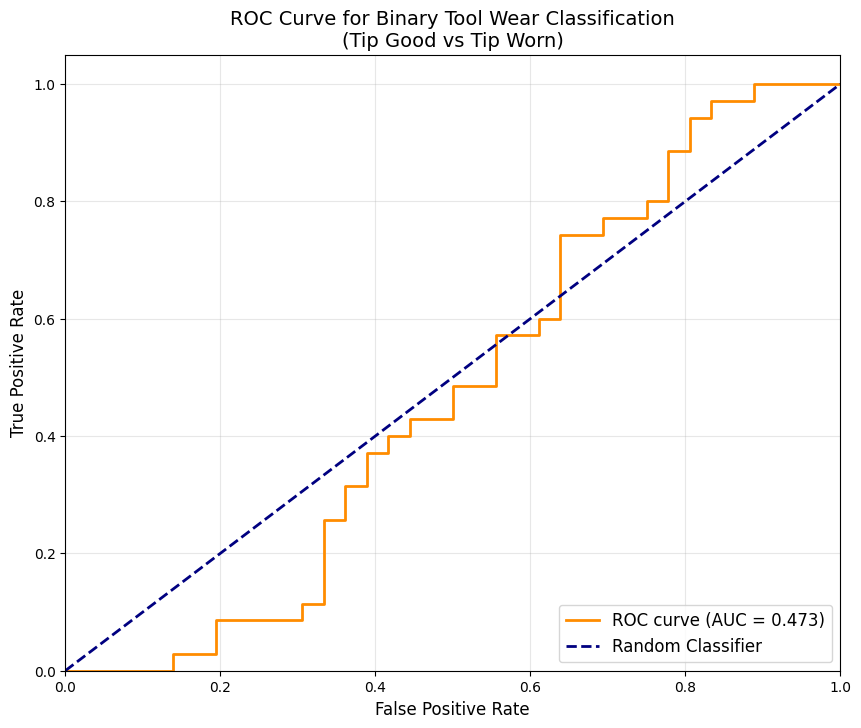

Generating Precision-Recall curve...


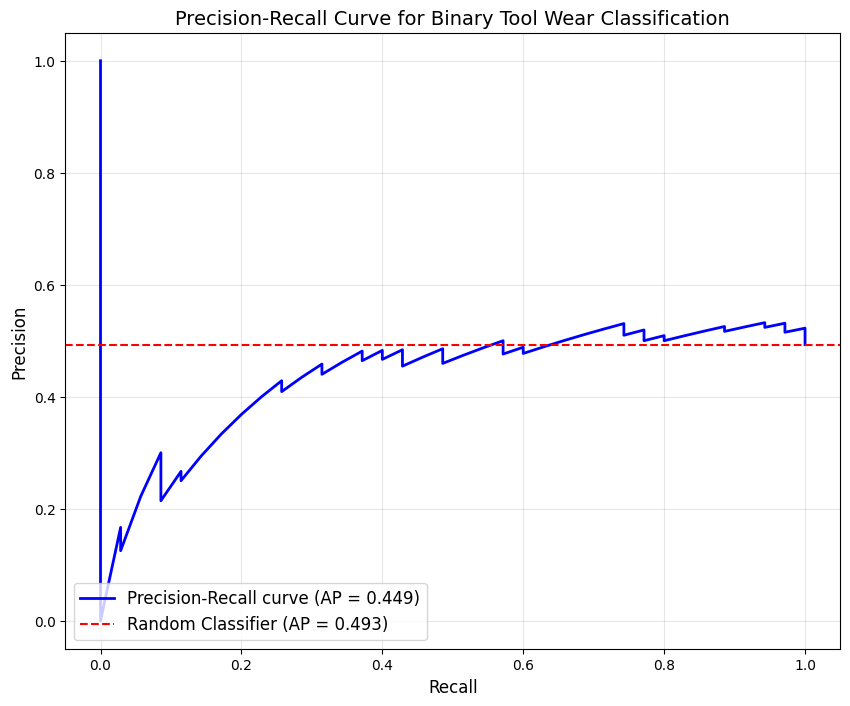

Generating confusion matrix...


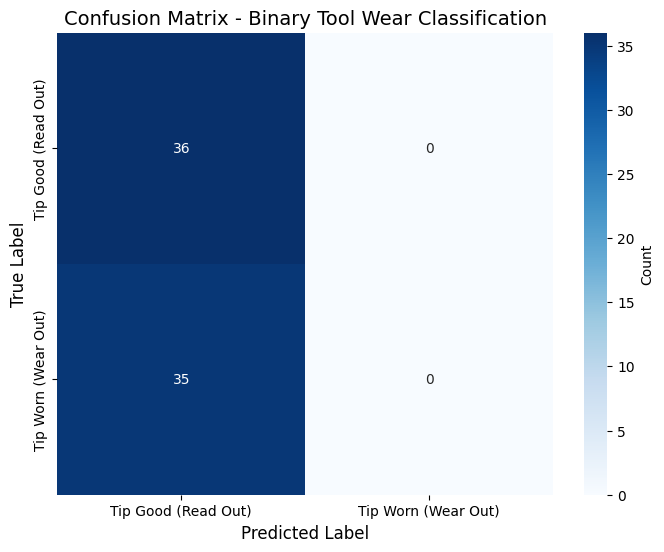

Generating probability distributions...


C:\Users\colin\AppData\Local\Temp\ipykernel_22508\966052065.py:301: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)


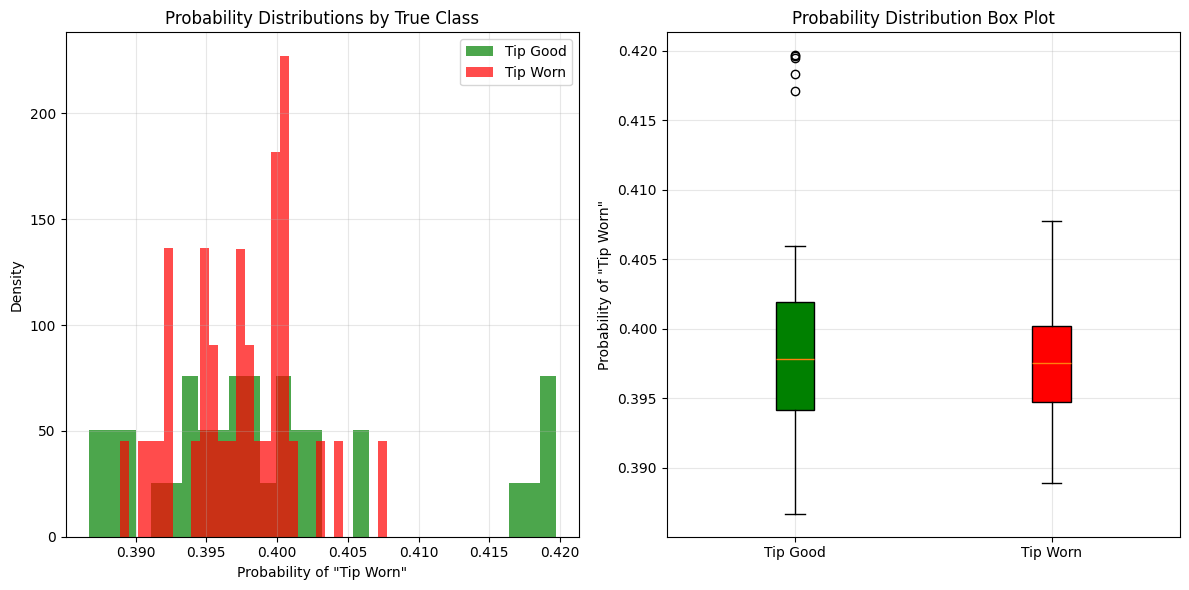


=== BINARY ROC ANALYSIS SUMMARY ===
Accuracy: 0.507
ROC AUC: 0.473
Average Precision: 0.449
Sensitivity (Recall for Tip Worn): 0.000
Specificity (Recall for Tip Good): 1.000
Precision (for Tip Worn): 0.000
Negative Predictive Value: 0.507

Confusion Matrix:
True Negatives (Tip Good correctly identified): 36
False Positives (Tip Good misclassified as Worn): 0
False Negatives (Tip Worn misclassified as Good): 35
True Positives (Tip Worn correctly identified): 0

Classification Report:
              precision    recall  f1-score   support

    Tip Good       0.51      1.00      0.67        36
    Tip Worn       0.00      0.00      0.00        35

    accuracy                           0.51        71
   macro avg       0.25      0.50      0.34        71
weighted avg       0.26      0.51      0.34        71


Results saved to: binary_roc_analysis

Binary ROC analysis completed!


C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

In [18]:

# Example usage
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Run complete binary ROC analysis
    results = run_complete_binary_roc_analysis(
        model_path="barlow_twins_classifier.pth",
        base_folder="exp_data/June 18",
        subfolders=["read_out", "wear_out"],
        output_dir="binary_roc_analysis",
        device=device
    )
    
    print("\nBinary ROC analysis completed!")

### As a Multiclass Classifier


In [19]:
def height_to_pil(height_array):
    """Convert AFM height array to PIL RGB image"""
    h_min, h_max = np.min(height_array), np.max(height_array)
    norm_img = 255 * (height_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)
    pil_img = Image.fromarray(norm_img)
    return pil_img.convert("RGB")

def extract_scan_index_from_filename(file_path):
    """Extract scan index from filename"""
    filename = os.path.basename(file_path)
    match = re.search(r'_(\d{4})', filename)
    if match:
        return int(match.group(1))
    match = re.search(r'(\d+)', filename)
    if match:
        return int(match.group(1))
    return 0

def create_3x3_crops(pil_img, crop_size=75):
    """Create 3x3 crops from PIL image"""
    w, h = pil_img.size
    x_positions = [0, (w - crop_size) // 2, w - crop_size]
    y_positions = [0, (h - crop_size) // 2, h - crop_size]
    crops = []
    for y in y_positions:
        for x in x_positions:
            crop = pil_img.crop((x, y, x + crop_size, y + crop_size)).resize((224, 224))
            crops.append(crop)
    return crops

class BarlowTwinsClassifier(nn.Module):
    def __init__(self, num_classes=5, include_reward_head=True, dropout_rate=0.3):
        super(BarlowTwinsClassifier, self).__init__()
        
        # Encoder (ResNet18)
        self.encoder = models.resnet18(pretrained=False)
        self.encoder.fc = nn.Identity()
        
        # Get feature dimension
        feature_dim = 512  # ResNet18 feature dimension
        
        # Add dropout
        self.dropout = nn.Dropout(dropout_rate)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )
        
        # Optional reward prediction head
        self.include_reward_head = include_reward_head
        if include_reward_head:
            self.reward_predictor = nn.Sequential(
                nn.Linear(feature_dim, 128),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(128, 1)
            )
    
    def forward(self, x, return_features=False):
        features = self.encoder(x)
        features = torch.flatten(features, 1)
        features = self.dropout(features)
        
        class_output = self.classifier(features)
        
        reward_output = None
        if self.include_reward_head:
            reward_output = self.reward_predictor(features)
        
        if return_features:
            return class_output, reward_output, features
        else:
            if self.include_reward_head:
                return class_output, reward_output
            else:
                return class_output

def load_multiclass_classifier(model_path, device='cpu', num_classes=5):
    """Load the trained multiclass classifier"""
    checkpoint = torch.load(model_path, map_location=device)
    has_reward_head = any(k.startswith("reward_predictor") for k in checkpoint['model_state_dict'].keys())
    
    model = BarlowTwinsClassifier(
        num_classes=num_classes, 
        include_reward_head=has_reward_head,
        dropout_rate=0.3
    )
    
    model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    model.to(device)
    model.eval()
    
    return model

def predict_with_probabilities(model, transform, ibw_file_path, device='cpu'):
    """Predict on a single IBW file and return class probabilities"""
    try:
        # Load IBW file
        ibw_data = load_ibw(ibw_file_path)
        height_img = ibw_data.z
        
        scan_index = extract_scan_index_from_filename(ibw_file_path)
        
        # Convert to PIL and create crops
        pil_img = height_to_pil(height_img)
        crops = create_3x3_crops(pil_img)
        crop_tensors = torch.stack([transform(c) for c in crops], dim=0).to(device)

        # Make predictions
        with torch.no_grad():
            if model.include_reward_head:
                outputs, _ = model(crop_tensors)
            else:
                outputs = model(crop_tensors)
                
            probs = torch.softmax(outputs, dim=1)
            avg_probs = probs.mean(dim=0)  # Average across all crops

        return {
            "file": ibw_file_path,
            "probabilities": avg_probs.cpu().numpy(),
            "scan_index": scan_index,
            "status": "success"
        }
        
    except Exception as e:
        return {
            "file": ibw_file_path,
            "probabilities": None,
            "scan_index": extract_scan_index_from_filename(ibw_file_path),
            "status": "error",
            "error": str(e)
        }

def generate_ground_truth_labels(files_data, subfolder_name, num_classes=5):
    """Generate ground truth labels based on subfolder and scan indices"""
    labels = []
    
    for data in files_data:
        scan_idx = data["scan_index"]
        
        if subfolder_name == "read_out":
            # Early scans should be fresh tips (class 0-1)
            if scan_idx <= 10:
                gt_label = 0  # Fresh Tip
            elif scan_idx <= 20:
                gt_label = 1  # Slight Wear
            else:
                gt_label = 2  # Moderate Wear
        else:  # wear_out
            # Later scans should be more worn (class 2-4)
            if scan_idx <= 10:
                gt_label = 2  # Moderate Wear
            elif scan_idx <= 20:
                gt_label = 3  # Significant Wear
            else:
                gt_label = 4  # Heavily Worn
        
        labels.append(gt_label)
    
    return labels

def collect_prediction_data(model_path, base_folder, subfolders=None, device='cpu', num_classes=5):
    """Collect prediction probabilities and ground truth labels for ROC analysis"""
    
    if subfolders is None:
        subfolders = ["read_out", "wear_out"]
    
    print(f"Collecting prediction data for ROC analysis...")
    print(f"Using device: {device}")
    
    # Load model
    model = load_multiclass_classifier(model_path, device, num_classes)
    
    # Setup transform
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    all_probabilities = []
    all_labels = []
    all_file_info = []
    
    for subfolder in subfolders:
        folder_path = os.path.join(base_folder, subfolder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} does not exist, skipping...")
            continue
            
        print(f"Processing {subfolder} folder...")
        
        # Get IBW files
        ibw_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) 
                    if f.lower().endswith('.ibw')]
        
        if not ibw_files:
            print(f"No IBW files found in {folder_path}")
            continue
        
        # Collect predictions
        subfolder_data = []
        for ibw_file in tqdm(ibw_files, desc=f"Processing {subfolder}"):
            result = predict_with_probabilities(model, transform, ibw_file, device)
            if result["status"] == "success":
                subfolder_data.append(result)
        
        # Generate ground truth labels for this subfolder
        gt_labels = generate_ground_truth_labels(subfolder_data, subfolder, num_classes)
        
        # Collect data
        for i, data in enumerate(subfolder_data):
            all_probabilities.append(data["probabilities"])
            all_labels.append(gt_labels[i])
            all_file_info.append({
                "file": data["file"],
                "subfolder": subfolder,
                "scan_index": data["scan_index"],
                "ground_truth": gt_labels[i]
            })
    
    return np.array(all_probabilities), np.array(all_labels), all_file_info

def plot_multiclass_roc_curves(y_true, y_probs, num_classes=5, output_dir="roc_analysis"):
    """Generate and save ROC curves for multiclass classification"""
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Class labels
    class_names = [
        "Fresh Tip",
        "Slight Wear", 
        "Moderate Wear",
        "Significant Wear",
        "Heavily Worn"
    ]
    
    # Binarize the output labels for multiclass ROC
    y_true_binarized = label_binarize(y_true, classes=list(range(num_classes)))
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Compute macro-average ROC curve and ROC area
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(num_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= num_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    
    # Plot all ROC curves
    plt.figure(figsize=(12, 8))
    
    # Colors for each class
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
    
    # Plot individual class ROC curves
    for i, color in zip(range(num_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
    
    # Plot micro and macro averages
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})',
             color='deeppink', linestyle=':', linewidth=4)
    
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'Macro-average (AUC = {roc_auc["macro"]:.2f})',
             color='navy', linestyle=':', linewidth=4)
    
    # Plot random classifier line
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves for Tool Wear Classification', fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Save the plot
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(output_dir, f'multiclass_roc_curves_{timestamp}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create a summary dataframe
    roc_summary = pd.DataFrame({
        'Class': class_names + ['Micro-Average', 'Macro-Average'],
        'AUC': [roc_auc[i] for i in range(num_classes)] + [roc_auc['micro'], roc_auc['macro']]
    })
    
    # Save summary
    roc_summary.to_csv(os.path.join(output_dir, f'roc_auc_summary_{timestamp}.csv'), index=False)
    
    return roc_auc, roc_summary

def plot_individual_class_roc(y_true, y_probs, num_classes=5, output_dir="roc_analysis"):
    """Plot individual ROC curves for each class"""
    
    class_names = [
        "Fresh Tip",
        "Slight Wear", 
        "Moderate Wear",
        "Significant Wear",
        "Heavily Worn"
    ]
    
    # Binarize the output labels
    y_true_binarized = label_binarize(y_true, classes=list(range(num_classes)))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        
        axes[i].plot(fpr, tpr, color='darkorange', lw=2,
                    label=f'ROC curve (AUC = {roc_auc:.2f})')
        axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[i].set_xlim([0.0, 1.0])
        axes[i].set_ylim([0.0, 1.05])
        axes[i].set_xlabel('False Positive Rate')
        axes[i].set_ylabel('True Positive Rate')
        axes[i].set_title(f'{class_names[i]}')
        axes[i].legend(loc="lower right")
        axes[i].grid(True, alpha=0.3)
    
    # Hide the last subplot if we have an odd number of classes
    if num_classes < 6:
        axes[-1].set_visible(False)
    
    plt.tight_layout()
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(output_dir, f'individual_roc_curves_{timestamp}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()

def generate_confusion_matrix_heatmap(y_true, y_pred, output_dir="roc_analysis"):
    """Generate a confusion matrix heatmap"""
    
    class_names = [
        "Fresh Tip",
        "Slight Wear", 
        "Moderate Wear",
        "Significant Wear",
        "Heavily Worn"
    ]
    
    from sklearn.metrics import confusion_matrix
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Tool Wear Classification')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(output_dir, f'confusion_matrix_{timestamp}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()

def run_complete_roc_analysis(model_path, base_folder, subfolders=None, 
                             output_dir="roc_analysis", device='cpu', num_classes=5):
    """Run complete ROC analysis including data collection and visualization"""
    
    print("=== STARTING ROC ANALYSIS ===")
    
    # Collect prediction data
    y_probs, y_true, file_info = collect_prediction_data(
        model_path, base_folder, subfolders, device, num_classes
    )
    
    if len(y_true) == 0:
        print("No valid prediction data found. Cannot generate ROC curves.")
        return
    
    print(f"Collected {len(y_true)} predictions for ROC analysis")
    
    # Generate predicted classes
    y_pred = np.argmax(y_probs, axis=1)
    
    # Calculate overall accuracy
    accuracy = np.mean(y_true == y_pred)
    print(f"Overall Accuracy: {accuracy:.3f}")
    
    # Generate ROC curves
    print("Generating ROC curves...")
    roc_auc, roc_summary = plot_multiclass_roc_curves(y_true, y_probs, num_classes, output_dir)
    
    # Generate individual class ROC curves
    print("Generating individual class ROC curves...")
    plot_individual_class_roc(y_true, y_probs, num_classes, output_dir)
    
    # Generate confusion matrix
    print("Generating confusion matrix...")
    generate_confusion_matrix_heatmap(y_true, y_pred, output_dir)
    
    # Save detailed results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Create detailed results dataframe
    detailed_results = []
    for i, info in enumerate(file_info):
        result = {
            'file': info['file'],
            'subfolder': info['subfolder'],
            'scan_index': info['scan_index'],
            'ground_truth': y_true[i],
            'predicted': y_pred[i],
            'correct': y_true[i] == y_pred[i],
            'confidence': y_probs[i][y_pred[i]]
        }
        # Add class probabilities
        for j in range(num_classes):
            result[f'prob_class_{j}'] = y_probs[i][j]
        detailed_results.append(result)
    
    results_df = pd.DataFrame(detailed_results)
    results_df.to_csv(os.path.join(output_dir, f'detailed_roc_results_{timestamp}.csv'), index=False)
    
    print(f"\n=== ROC ANALYSIS SUMMARY ===")
    print(roc_summary)
    print(f"\nResults saved to: {output_dir}")
    
    return roc_auc, roc_summary, results_df

C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(


=== STARTING ROC ANALYSIS ===
Using device: cuda


C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Processing read_out folder...


Processing read_out: 100%|██████████| 36/36 [00:03<00:00,  9.01it/s]


Processing wear_out folder...


Processing wear_out: 100%|██████████| 35/35 [00:03<00:00,  9.41it/s]


Collected 71 predictions for ROC analysis
Overall Accuracy: 0.352
Generating ROC curves...


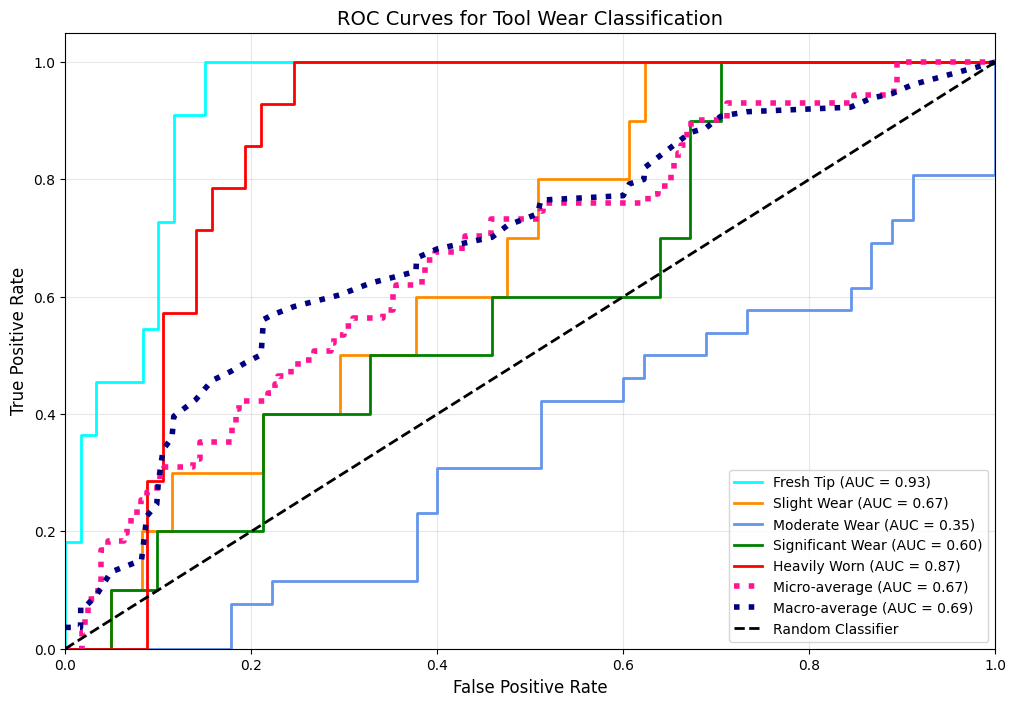

Generating individual class ROC curves...


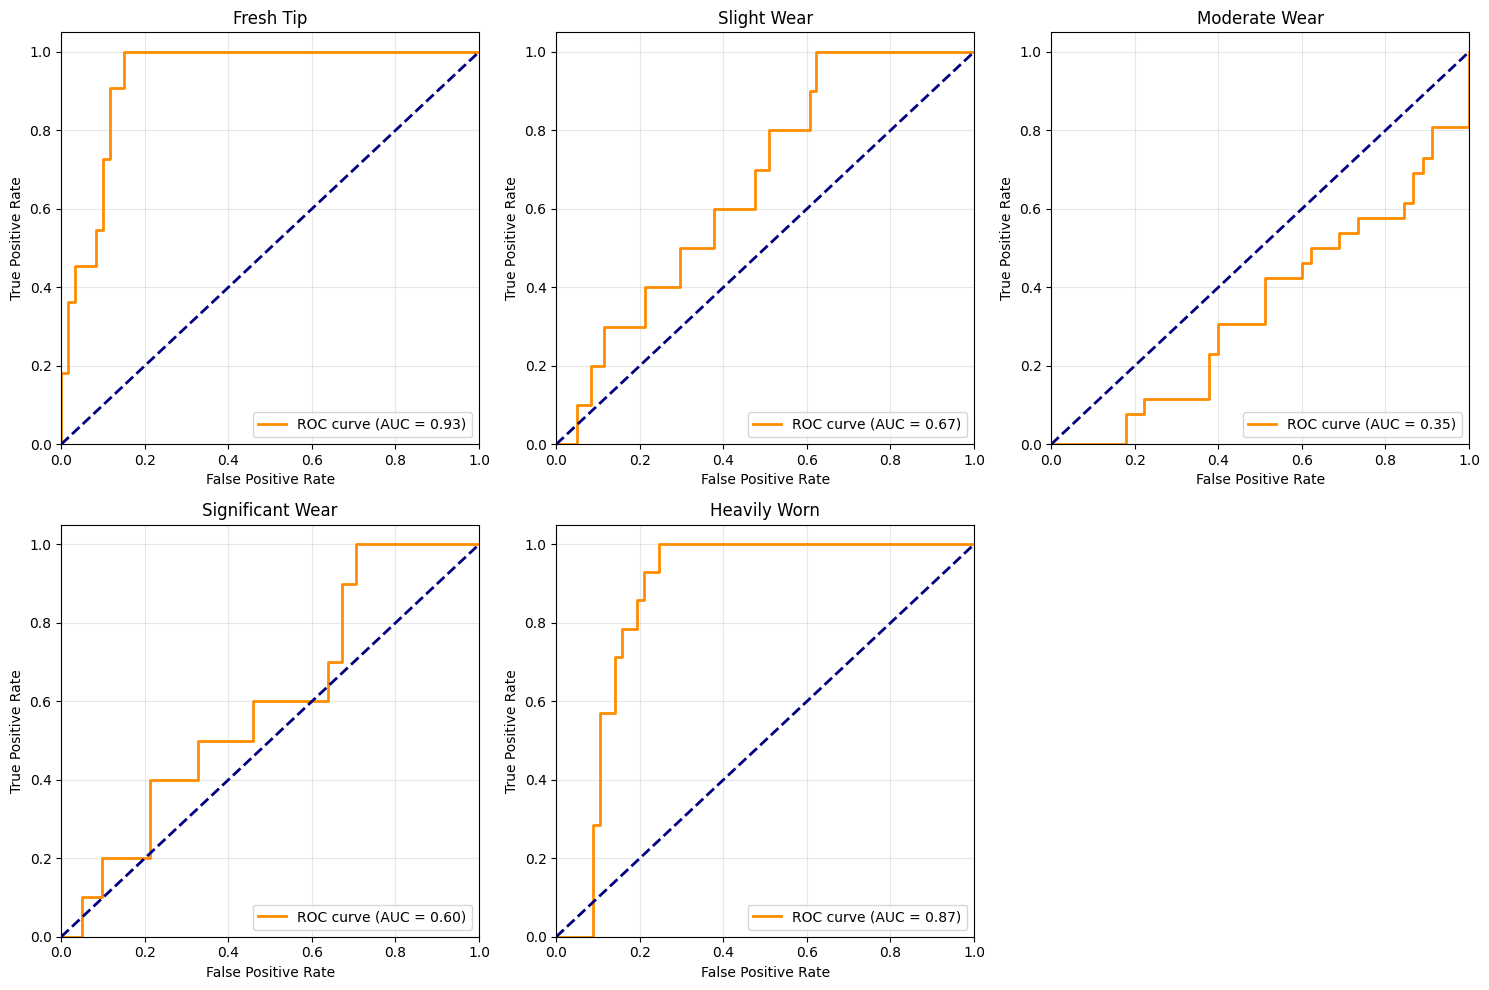

Generating confusion matrix...


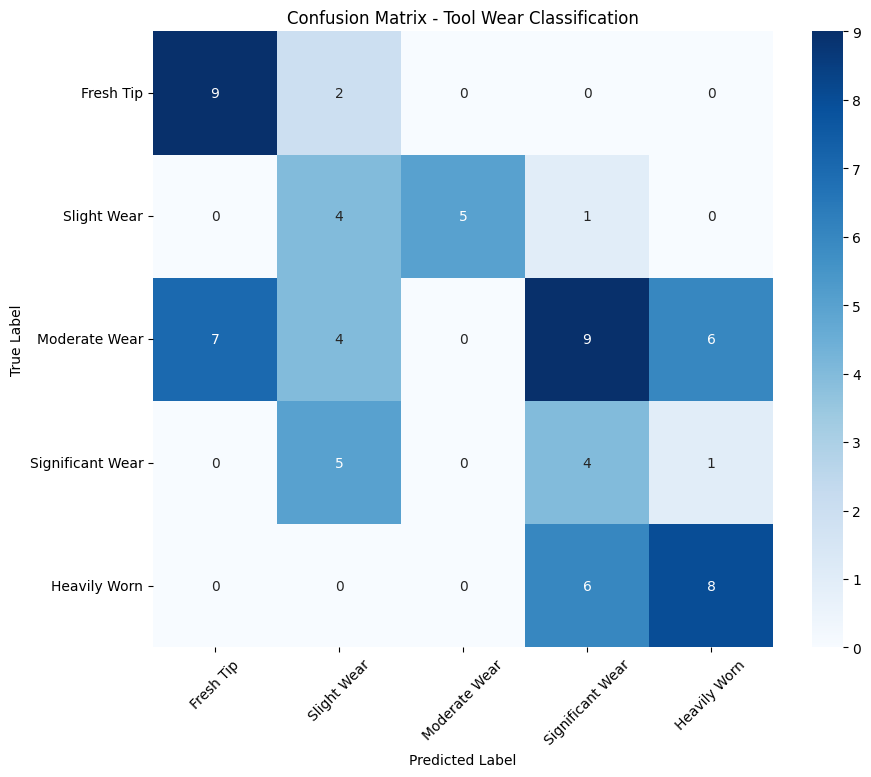


=== ROC ANALYSIS SUMMARY ===
              Class       AUC
0         Fresh Tip  0.933333
1       Slight Wear  0.665574
2     Moderate Wear  0.347009
3  Significant Wear  0.595082
4      Heavily Worn  0.867168
5     Micro-Average  0.672436
6     Macro-Average  0.690889

Results saved to: roc_analysis

ROC analysis completed!


In [20]:
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Run complete ROC analysis
    roc_auc, summary, detailed_results = run_complete_roc_analysis(
        model_path="barlow_twins_multiclass_classifier.pth",
        base_folder="exp_data/June 18",
        subfolders=["read_out", "wear_out"],
        output_dir="roc_analysis",
        device=device,
        num_classes=5
    )
    
    print("\nROC analysis completed!")

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def plot_classification_vs_scan_index(results, title="Classification vs Scan Index with Trendlines"):
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.linear_model import LinearRegression

    scan_indices = []
    predicted_classes = []
    confidences = []
    categories = []

    for r in results:
        if 'scan_index' in r and r['scan_index'] is not None and r['predicted_class'] is not None:
            scan_indices.append(r['scan_index'])
            predicted_classes.append(r['predicted_class'])
            confidences.append(r['confidence'])
            if 'read_out' in r['file'].lower():
                categories.append('read_out')
            elif 'wear_out' in r['file'].lower():
                categories.append('wear_out')
            else:
                categories.append('unknown')

    scan_indices = np.array(scan_indices)
    predicted_classes = np.array(predicted_classes)
    confidences = np.array(confidences)
    categories = np.array(categories)

    plt.figure(figsize=(10, 6))

    # Plot read_out
    read_mask = categories == 'read_out'
    plt.scatter(scan_indices[read_mask], predicted_classes[read_mask],
                c=confidences[read_mask], cmap='viridis', marker='o', s=50, label='Read Out')

    # Plot wear_out
    wear_mask = categories == 'wear_out'
    plt.scatter(scan_indices[wear_mask], predicted_classes[wear_mask],
                c=confidences[wear_mask], cmap='viridis', marker='s', s=50, label='Wear Out')

    # Trendlines
    for mask, label, color in zip([read_mask, wear_mask], ['Read Out', 'Wear Out'], ['blue', 'red']):
        if np.sum(mask) > 1:
            X = scan_indices[mask].reshape(-1, 1)
            y = predicted_classes[mask]
            model = LinearRegression()
            model.fit(X, y)
            x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
            y_line = model.predict(x_line)
            plt.plot(x_line, y_line, color=color, linestyle='--', label=f'{label} Trend')

    plt.colorbar(label="Confidence")
    plt.xlabel("Scan Index")
    plt.ylabel("Predicted Class")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_confidence_vs_predicted_class(results, title="Confidence vs Predicted Class"):
    import matplotlib.pyplot as plt
    import numpy as np

    predicted_classes = []
    confidences = []
    categories = []

    for r in results:
        if r['predicted_class'] is not None and r['confidence'] is not None:
            # Ensure predicted_class is integer (discrete)
            predicted_classes.append(int(r['predicted_class']))
            # Optionally, round confidence to nearest 2 decimals for x-axis clarity, but keep as float
            confidences.append(r['confidence'])
            if 'read_out' in r['file'].lower():
                categories.append('read_out')
            elif 'wear_out' in r['file'].lower():
                categories.append('wear_out')
            else:
                categories.append('unknown')

    predicted_classes = np.array(predicted_classes)
    confidences = np.array(confidences)
    categories = np.array(categories)

    plt.figure(figsize=(10, 6))

    read_mask = categories == 'read_out'
    wear_mask = categories == 'wear_out'

    plt.scatter(confidences[read_mask], predicted_classes[read_mask], color='blue', marker='o', label='Read Out', alpha=0.7)
    plt.scatter(confidences[wear_mask], predicted_classes[wear_mask], color='red', marker='s', label='Wear Out', alpha=0.7)

    plt.xlabel("Confidence")
    plt.ylabel("Predicted Class")
    plt.title(title)
    plt.yticks(sorted(set(predicted_classes)))  # Only show integer class ticks
    plt.legend()
    plt.grid(True)
    plt.show()



import os

def extract_scan_index_from_filename(file_path):
    """Extracts scan index (number) from filename like 'Wear_out_0015.ibw'."""
    import re
    filename = os.path.basename(file_path)
    match = re.search(r'_(\d{4})', filename)
    if match:
        return int(match.group(1))
    # Fallback: use first number found
    match = re.search(r'(\d+)', filename)
    if match:
        return int(match.group(1))
    return 0  # Default fallback if no number found

def preprocess_height_channel(height_np_array, transform=None):
    """
    Normalize the Height channel to [0, 255], convert to PIL Image,
    duplicate single channel to 3 channels, apply transforms.
    """
    # Normalize to 0-255
    h_min = np.min(height_np_array)
    h_max = np.max(height_np_array)
    norm_img = 255 * (height_np_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)

    # Convert to PIL image
    pil_img = Image.fromarray(norm_img)

    # Convert grayscale to RGB by duplicating channels
    pil_img = pil_img.convert("RGB")

    if transform:
        return transform(pil_img)
    else:
        # Default tensor transform if none given
        return transforms.ToTensor()(pil_img)


C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\colin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Processing exp_data/June 18\read_out\Read_out_0000.ibw...
Processing exp_data/June 18\read_out\Read_out_0001.ibw...
Processing exp_data/June 18\read_out\Read_out_0002.ibw...
Processing exp_data/June 18\read_out\Read_out_0003.ibw...
Processing exp_data/June 18\read_out\Read_out_0004.ibw...
Processing exp_data/June 18\read_out\Read_out_0005.ibw...
Processing exp_data/June 18\read_out\Read_out_0006.ibw...
Processing exp_data/June 18\read_out\Read_out_0007.ibw...
Processing exp_data/June 18\read_out\Read_out_0008.ibw...
Processing exp_data/June 18\read_out\Read_out_0009.ibw...
Processing exp_data/June 18\read_out\Read_out_0010.ibw...
Processing exp_data/June 18\read_out\Read_out_0011.ibw...
Processing exp_data/June 18\read_out\Read_out_0012.ibw...
Processing exp_data/June 18\read_out\Read_out_0013.ibw...
Processing exp_data/June 18\read_out\Read_out_0014.ibw...
Processing exp_data/June 18\read_out\Read_out_0015.ibw...
Processing exp_data/June 18\read_out\Read_out_0016.ibw...
Processing exp

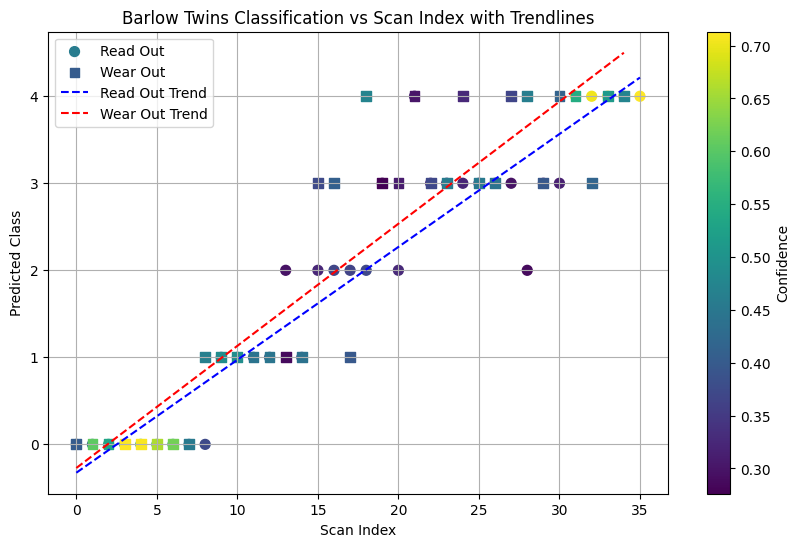

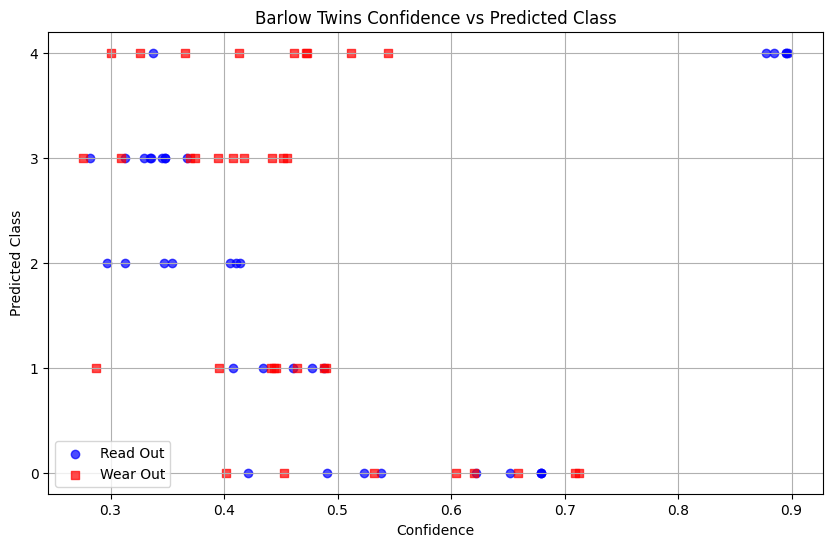

In [34]:
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "best_barlow_classifier.pth"

model = load_multiclass_classifier(model_path, device=device, num_classes=5)

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# Use the subfolders variable already defined: ['read_out', 'wear_out']
base_dir = "exp_data/June 18"
ibw_file_paths = []
for subfolder in subfolders:
    folder_path = os.path.join(base_dir, subfolder)
    if os.path.exists(folder_path):
        ibw_file_paths += [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(".ibw")]

results = []
for file_path in ibw_file_paths:
    print(f"Processing {file_path}...")
    result = predict_with_probabilities(model, transform, file_path, device=device)
    results.append(result)

# Add predicted_class and confidence for each result
for r in results:
    if r["status"] == "success" and r["probabilities"] is not None:
        r["predicted_class"] = np.argmax(r["probabilities"])
        r["confidence"] = float(r["probabilities"][r["predicted_class"]])
    else:
        r["predicted_class"] = None
        r["confidence"] = None

print(f"Total files processed: {len(results)}")

plot_classification_vs_scan_index(results, title="Barlow Twins Classification vs Scan Index with Trendlines")
plot_confidence_vs_predicted_class(results, title="Barlow Twins Confidence vs Predicted Class")

